## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Kecamatan mana yang menghasilkan sampah paling banyak?
- Pertanyaan 2: Jenis sampah apa yang paling sering muncul dan bagaimana metode pengelolaan terbaiknya?
- Pertanyaan 3: Apakah cuaca mempengaruhi jumlah berat sampah yang dihasilkan?

### Insight:
Pada tahap ini, pertanyaan-pertanyaan bisnis telah diidentifikasi untuk memandu analisis data sampah. Pertanyaan-pertanyaan ini akan fokus pada identifikasi kecamatan dengan volume sampah tertinggi, jenis sampah yang paling umum beserta metode pengelolaannya, dan dampak cuaca terhadap jumlah sampah. Jawaban atas pertanyaan-pertanyaan ini akan memberikan dasar untuk rekomendasi pengelolaan sampah yang lebih efektif.

## Import Library/Packages yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

sns.set_style('whitegrid')

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Wrangling

### Gathering Data

In [ ]:
df = pd.read_csv('/content/dataset_sampah_mentah_realistis_2018_2025.csv')

display(df.head())

,tahun,bulan,kecamatan,jenis_sampah,berat_kg,volume_liter,moisture_level,biodegradable,recyclable,toxic,sumber,cuaca,suhu_celsius,tingkat_bau,kondisi_sampah,metode_pengelolaan,estimasi_nilai_daur_ulang_rp,catatan_petugas,label
0,2018,3,Kebon Jeruk,organik,0.92,2.50,0.87,1,1.0,0,komersial,mendung,20.4,9,normal,daur ulang,2421.0,tercampur limbah lain,organik
1,2018,12,Menteng,organik,1.14,1.92,0.71,1,0.0,0,rumah tangga,hujan,30.2,6,tercampur,dibakar,3875.0,perlu dipilah,organik
2,2018,9,Kebon Jeruk,organik,1.26,3.93,0.91,1,0.0,0,rumah tangga,NaN,25.5,9,tercampur,kompos,4102.0,perlu dipilah,organik
3,2018,8,Pasar Minggu,organik,1.04,3.22,0.83,1,0.0,0,komersial,cerah,29.5,7,rusak,dibakar,5911.0,perlu dipilah,organik
4,2018,4,Penjaringan,organik,0.50,1.60,0.55,1,0.0,0,rumah tangga,cerah,26.7,8,basah,kompos,2108.0,kondisi basah,organik


### Insight:
Proses pengumpulan data melibatkan pemuatan dataset 'dataset_sampah_mentah_realistis_2018_2025.csv' ke dalam DataFrame pandas. Dataset ini berisi data historis sampah dari tahun 2018 hingga 2025, yang akan digunakan untuk menjawab pertanyaan bisnis yang telah ditetapkan. Tahap ini krusial untuk memastikan ketersediaan data yang relevan sebelum melanjutkan ke analisis lebih dalam.

### Assessing Data

In [ ]:
print("Informasi Dataset")
display(df.info())

print("\nUkuran Dataset")
print(df.shape)

print("\nStatistik Deskriptif")
display(df.describe())

print("\nMissing Value")
display(df.isnull().sum())

print("\nData Duplikat")
print(df.duplicated().sum())

Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 369214 entries, 0 to 369213
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   tahun                         369214 non-null  int64  
 1   bulan                         369214 non-null  int64  
 2   kecamatan                     369214 non-null  object 
 3   jenis_sampah                  369214 non-null  object 
 4   berat_kg                      351082 non-null  float64
 5   volume_liter                  361062 non-null  float64
 6   moisture_level                349655 non-null  float64
 7   biodegradable                 369214 non-null  int64  
 8   recyclable                    353149 non-null  float64
 9   toxic                         369214 non-null  int64  
 10  sumber                        356924 non-null  object 
 11  cuaca                         353712 non-null  object 
 12  suhu_celsius              

None


Ukuran Dataset
(369214, 19)

Statistik Deskriptif


,tahun,bulan,berat_kg,volume_liter,moisture_level,biodegradable,recyclable,toxic,suhu_celsius,tingkat_bau,estimasi_nilai_daur_ulang_rp
count,369214.000000,369214.000000,351082.000000,361062.000000,349655.000000,369214.000000,353149.000000,369214.000000,353339.000000,369214.000000,369214.000000
mean,2021.641587,6.509228,0.704709,1.831236,0.497949,0.549356,0.332726,0.010349,29.003345,4.992397,3057.740906
std,2.286756,3.453788,0.726876,1.213966,0.296407,0.497559,0.471190,0.101202,3.999458,2.574675,1879.710992
min,2018.000000,1.000000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,10.500000,1.000000,0.000000
25%,2020.000000,4.000000,0.390000,0.930000,0.220000,0.000000,0.000000,0.000000,26.300000,3.000000,1661.000000
50%,2022.000000,7.000000,0.620000,1.600000,0.540000,1.000000,0.000000,0.000000,29.000000,5.000000,3003.000000
75%,2024.000000,10.000000,0.890000,2.510000,0.760000,1.000000,1.000000,0.000000,31.700000,7.000000,4348.000000
max,2025.000000,12.000000,19.991795,9.590000,0.980000,1.000000,1.000000,1.000000,48.100000,9.000000,12360.000000



Missing Value


,0
tahun,0
bulan,0
kecamatan,0
jenis_sampah,0
berat_kg,18132
volume_liter,8152
moisture_level,19559
biodegradable,0
recyclable,16065
toxic,0



Data Duplikat
6661


### Insight:
- **Informasi Dataset:** Ditemukan adanya missing values pada beberapa kolom seperti `berat_kg`, `volume_liter`, `moisture_level`, `recyclable`, `sumber`, `cuaca`, `suhu_celsius`, dan `catatan_petugas`.
- **Ukuran Dataset:** Dataset memiliki 369.214 baris dan 19 kolom.
- **Statistik Deskriptif:** Memberikan gambaran umum distribusi data numerik.
- **Missing Value:** Konfirmasi kembali jumlah missing values per kolom.
- **Data Duplikat:** Ditemukan adanya 6.661 data duplikat yang perlu ditangani.

### Cleaning Data

### Duplicate value

In [ ]:
jumlah_duplikat = df.duplicated().sum()
print(f"Ditemukan {jumlah_duplikat} baris data duplikat.")

if jumlah_duplikat > 0:
    df.drop_duplicates(inplace=True)
    print("-> Data duplikat berhasil dihapus!")

Ditemukan 6661 baris data duplikat.
-> Data duplikat berhasil dihapus!


# Insight:
 * Deteksi Data: Mengidentifikasi dan menghitung total baris data yang sama persis (duplikat) di dalam dataset, yang dalam kasus ini terdeteksi sebanyak 6.661 baris.

* Efisiensi Kode: Menggunakan fungsi kondisional (if) untuk memastikan proses penghapusan hanya dilakukan jika sistem benar-benar menemukan adanya data ganda.

* Pembersihan Data: Menghapus baris data duplikat secara langsung pada dataset utama (inplace=True) tanpa membuat salinan baru, sehingga menghemat penggunaan memori.

* Integritas Data: Memastikan setiap baris data yang tersisa di dalam dataset adalah unik untuk mencegah terjadinya perhitungan ganda (double-counting) atau bias pada hasil analisis dan kesimpulan nanti.




# Missing Value

In [ ]:
df.drop_duplicates(inplace=True)

numerik = [
    'berat_kg',
    'volume_liter',
    'moisture_level',
    'suhu_celsius'
]

kategori = [
    'recyclable',
    'sumber',
    'cuaca',
    'catatan_petugas'
]

for kolom in numerik:
    df[kolom] = df[kolom].fillna(
        df[kolom].median()
    )

for kolom in kategori:
    df[kolom] = df[kolom].fillna(
        df[kolom].mode()[0]
    )

print("Data Setelah Cleaning")
display(df.isnull().sum())

Data Setelah Cleaning


,0
tahun,0
bulan,0
kecamatan,0
jenis_sampah,0
berat_kg,0
volume_liter,0
moisture_level,0
biodegradable,0
recyclable,0
toxic,0


### Insight:
Setelah proses cleaning data, yaitu penghapusan duplikat dan pengisian nilai yang hilang (`NaN`) untuk kolom numerik dengan median dan kolom kategorikal dengan modus, kini tidak ada lagi missing values dalam dataset. Ini memastikan data siap untuk analisis lebih lanjut.

# Feature Engginering

In [ ]:
df['kepadatan'] = df['berat_kg'] / (df['volume_liter'] + 0.01)

df['periode'] = pd.to_datetime(df['tahun'].astype(str) + '-' + df['bulan'].astype(str).str.zfill(2) + '-01')

batas_bawah = df['estimasi_nilai_daur_ulang_rp'].quantile(0.33)
batas_atas = df['estimasi_nilai_daur_ulang_rp'].quantile(0.66)

def kategori_nilai(nilai):
    if nilai <= batas_bawah: return 'Rendah'
    elif nilai <= batas_atas: return 'Sedang'
    else: return 'Tinggi'

df['kategori_nilai_ekonomi'] = df['estimasi_nilai_daur_ulang_rp'].apply(kategori_nilai)
print(df.head())

   tahun  bulan     kecamatan jenis_sampah  berat_kg  volume_liter  \
0   2018      3   Kebon Jeruk      organik      0.92          2.50   
1   2018     12       Menteng      organik      1.14          1.92   
2   2018      9   Kebon Jeruk      organik      1.26          3.93   
3   2018      8  Pasar Minggu      organik      1.04          3.22   
4   2018      4   Penjaringan      organik      0.50          1.60   

   moisture_level  biodegradable  recyclable  toxic  ... suhu_celsius  \
0            0.87              1         1.0      0  ...         20.4   
1            0.71              1         0.0      0  ...         30.2   
2            0.91              1         0.0      0  ...         25.5   
3            0.83              1         0.0      0  ...         29.5   
4            0.55              1         0.0      0  ...         26.7   

  tingkat_bau  kondisi_sampah  metode_pengelolaan  \
0           9          normal          daur ulang   
1           6       tercampur     

# Insight :
Pada tahap *Feature Engineering*, kita telah berhasil menciptakan 3 fitur (kolom) baru yang memberikan nilai tambah signifikan untuk analisis lanjutan maupun pemodelan *Machine Learning*:

1. **`kepadatan` (Density Sampah):** Fitur ini didapatkan dari pembagian `berat_kg` dengan `volume_liter`.
   * **Makna Bisnis:** Mengetahui kepadatan sangat krusial untuk logistik. Sampah yang berat tapi volumenya kecil (kepadatan tinggi) membutuhkan penanganan armada yang berbeda dibandingkan sampah ringan namun memakan banyak tempat (kepadatan rendah). Ini membantu optimalisasi ruang di dalam truk pengangkut.

2. **`periode` (Format Waktu Time-Series):** Menggabungkan kolom `tahun` dan `bulan` menjadi satu format tanggal standar (`YYYY-MM-DD`).
   * **Makna Bisnis:** Memudahkan kita untuk melakukan analisis tren waktu (*Time-Series Analysis*). Dengan format ini, kita bisa melihat pergerakan visualisasi data dari waktu ke waktu dengan lebih mulus (misalnya: apakah ada lonjakan volume sampah di bulan-bulan tertentu dari tahun 2018 hingga 2025).

3. **`kategori_nilai_ekonomi` (Segmentasi Potensi Daur Ulang):** Mengubah nilai numerik `estimasi_nilai_daur_ulang_rp` menjadi kategori diskrit ('Rendah', 'Sedang', 'Tinggi') menggunakan perhitungan persentil (*quantile*).
   * **Makna Bisnis:** Fitur ini sangat berguna untuk pengambilan keputusan strategis. Daripada melihat angka rupiah yang acak, pemangku kepentingan (seperti pengelola bank sampah) bisa langsung memfilter dan memprioritaskan jenis atau wilayah mana yang menghasilkan sampah dengan kategori "Tinggi" untuk dimaksimalkan potensi ekonomi sirkularnya.



In [ ]:
df['rasio_kelembaban_berat'] = (
    df['moisture_level'] / (df['berat_kg'] + 0.01)
)

df['kategori_suhu'] = pd.cut(
    df['suhu_celsius'],
    bins=[0, 25, 35, 100],
    labels=['Dingin', 'Normal', 'Panas']
)

df['efisiensi_ruang'] = (
    df['volume_liter'] / (df['berat_kg'] + 0.01)
)

df['cuaca_encoded'] = df['cuaca'].astype('category').cat.codes

df['kuartal'] = (
    (df['bulan'] - 1) // 3
) + 1

### Insight:
Kita telah berhasil menambahkan 5 fitur (kolom) baru yang memberikan nilai tambah signifikan untuk analisis lanjutan maupun pemodelan *Machine Learning*:

1.  **`rasio_kelembaban_berat` (Moisture-to-Weight Ratio):** Fitur ini didapatkan dari pembagian `moisture_level` dengan `berat_kg`.
    *   **Makna Bisnis:** Rasio ini penting untuk memahami karakteristik sampah, terutama dalam proses pengolahan seperti pengomposan atau insinerasi. Sampah dengan rasio kelembaban-berat tinggi mungkin memerlukan penanganan khusus untuk mengurangi kadar air sebelum diproses lebih lanjut, yang dapat memengaruhi biaya operasional.

2.  **`kategori_suhu` (Temperature Categories):** Mengkategorikan suhu (`suhu_celsius`) menjadi 'Dingin', 'Normal', atau 'Panas' berdasarkan rentang tertentu.
    *   **Makna Bisnis:** Fitur kategorikal ini membantu mengidentifikasi bagaimana suhu lingkungan dapat berkorelasi dengan jumlah atau jenis sampah yang dihasilkan, atau bahkan kondisi dekomposisi sampah. Ini bisa menjadi faktor penting dalam perencanaan pengumpulan sampah dan pengelolaan fasilitas.

3.  **`efisiensi_ruang` (Space Efficiency):** Fitur ini menghitung seberapa efisien volume terisi oleh berat sampah, didapatkan dari pembagian `volume_liter` dengan `berat_kg`.
    *   **Makna Bisnis:** Mirip dengan kepadatan, efisiensi ruang memberikan perspektif terbalik. Ini membantu dalam mengoptimalkan kapasitas truk pengangkut atau tempat penampungan sementara. Sampah dengan efisiensi ruang tinggi (volume besar, berat ringan) memerlukan pertimbangan logistik yang berbeda.

4.  **`cuaca_encoded` (Encoded Weather):** Mengubah fitur kategorikal `cuaca` menjadi representasi numerik menggunakan label encoding.
    *   **Makna Bisnis:** Fitur ini penting untuk model machine learning yang umumnya membutuhkan input numerik. Dengan mengkodekan cuaca, kita dapat menganalisis dan memodelkan dampak cuaca terhadap volume atau jenis sampah secara kuantitatif, tanpa perlu mengkhawatirkan format data non-numerik.

5.  **`kuartal` (Quarter of the Year):** Mengidentifikasi kuartal tahun (1, 2, 3, 4) berdasarkan bulan.
    *   **Makna Bisnis:** Fitur ini memungkinkan analisis tren musiman yang lebih granular. Dengan mengetahui kuartal, kita dapat mengidentifikasi pola peningkatan atau penurunan volume sampah pada periode tertentu dalam setahun, yang dapat membantu dalam alokasi sumber daya dan perencanaan strategis jangka pendek.

# Export Data Bersih


In [ ]:
clean_file_path = '/content/drive/MyDrive/Dataset/Dataset_Sampah_Cleaned_2018_2025.csv'
df.to_csv(clean_file_path, index=False)
print(f"\nData bersih berhasil disimpan di:\n{clean_file_path}")


Data bersih berhasil disimpan di:
/content/drive/MyDrive/Dataset/Dataset_Sampah_Cleaned_2018_2025.csv


### Exploratory Data Analysis (EDA)

In [ ]:
# EDA Pertanyaan 1: Kecamatan penghasil sampah paling banyak (berdasarkan total berat)
sampah_per_kecamatan = df.groupby('kecamatan')['berat_kg'].sum().sort_values(ascending=False).reset_index()
print("--- Top 10 Kecamatan Penghasil Sampah Terbesar (Total Kg) ---")
display(sampah_per_kecamatan.head(10))

# EDA Pertanyaan 2: Jenis sampah yang paling sering muncul
jenis_sampah_freq = df['jenis_sampah'].value_counts().reset_index()
jenis_sampah_freq.columns = ['jenis_sampah', 'jumlah_kemunculan']
print("\n--- Frekuensi Kemunculan Jenis Sampah ---")
display(jenis_sampah_freq)

# Melihat hubungan antara jenis sampah dominan dengan metode pengelolaan yang digunakan
pengelolaan_organik = df[df['jenis_sampah'] == 'organik']['metode_pengelolaan'].value_counts().reset_index()
print("\n--- Metode Pengelolaan untuk Sampah Organik (Jenis Terbanyak) ---")
display(pengelolaan_organik)

# EDA Pertanyaan 3: Rata-rata berat sampah berdasarkan kondisi cuaca
berat_per_cuaca = df.groupby('cuaca')['berat_kg'].mean().sort_values(ascending=False).reset_index()
print("\n--- Rata-rata Berat Sampah (Kg) per Kondisi Cuaca ---")
display(berat_per_cuaca)

--- Top 10 Kecamatan Penghasil Sampah Terbesar (Total Kg) ---


,kecamatan,berat_kg
0,Cilandak,21341.718522
1,Pasar Minggu,21075.062760
2,Cengkareng,20807.137900
3,Menteng,20799.027885
4,Kebon Jeruk,20776.264496
5,Penjaringan,20732.589688
6,Jagakarsa,20705.248762
7,Pulogadung,20687.085418
8,Kramat Jati,20628.841765
9,Kemayoran,20605.142705



--- Frekuensi Kemunculan Jenis Sampah ---


,jenis_sampah,jumlah_kemunculan
0,organik,196952
1,kertas,64149
2,plastik,49202
3,lain-lain,26422
4,gelas kaca,7869
5,logam metal,5192
6,sampah B3,3757
7,kain tekstil,3096
8,kayu,2214
9,sampah bongkaran,2118



--- Metode Pengelolaan untuk Sampah Organik (Jenis Terbanyak) ---


,metode_pengelolaan,count
0,bank sampah,39642
1,dibakar,39559
2,daur ulang,39416
3,TPA,39189
4,kompos,39146



--- Rata-rata Berat Sampah (Kg) per Kondisi Cuaca ---


,cuaca,berat_kg
0,cerah,0.703166
1,hujan,0.700638
2,mendung,0.699867


### Insight:
Dari hasil EDA awal, ditemukan beberapa poin penting:

*   **Kecamatan Penyumbang Sampah Terbesar:** Kecamatan `Cilandak`, `Pasar Minggu`, dan `Cengkareng` secara konsisten menjadi tiga besar penyumbang berat sampah terbanyak. Hal ini mengindikasikan bahwa wilayah-wilayah ini memerlukan perhatian khusus dalam strategi pengelolaan sampah.

*   **Jenis Sampah Dominan:** `Organik` adalah jenis sampah yang paling sering muncul, diikuti oleh `kertas` dan `plastik`. Ini menyoroti pentingnya fokus pada pengelolaan sampah organik (misalnya melalui pengomposan atau biogas) dan pengembangan program daur ulang yang efektif untuk sampah anorganik.

*   **Metode Pengelolaan Sampah Organik:** Untuk sampah organik, metode pengelolaan yang paling umum adalah `bank sampah`, `dibakar`, dan `daur ulang`. Menariknya, metode `kompos` dan `TPA` juga memiliki proporsi yang signifikan.

*   **Pengaruh Cuaca:** Rata-rata berat sampah tidak menunjukkan perbedaan yang signifikan antar kondisi cuaca (`cerah`, `hujan`, `mendung`). Meskipun ada fluktuasi kecil, cuaca tampaknya bukan faktor utama yang mempengaruhi volume total sampah.

### Visualization & Explanatory Analysis

### Pertanyaan 1 : Kecamatan mana yang menghasilkan sampah paling banyak?

/tmp/ipykernel_3375/603777677.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


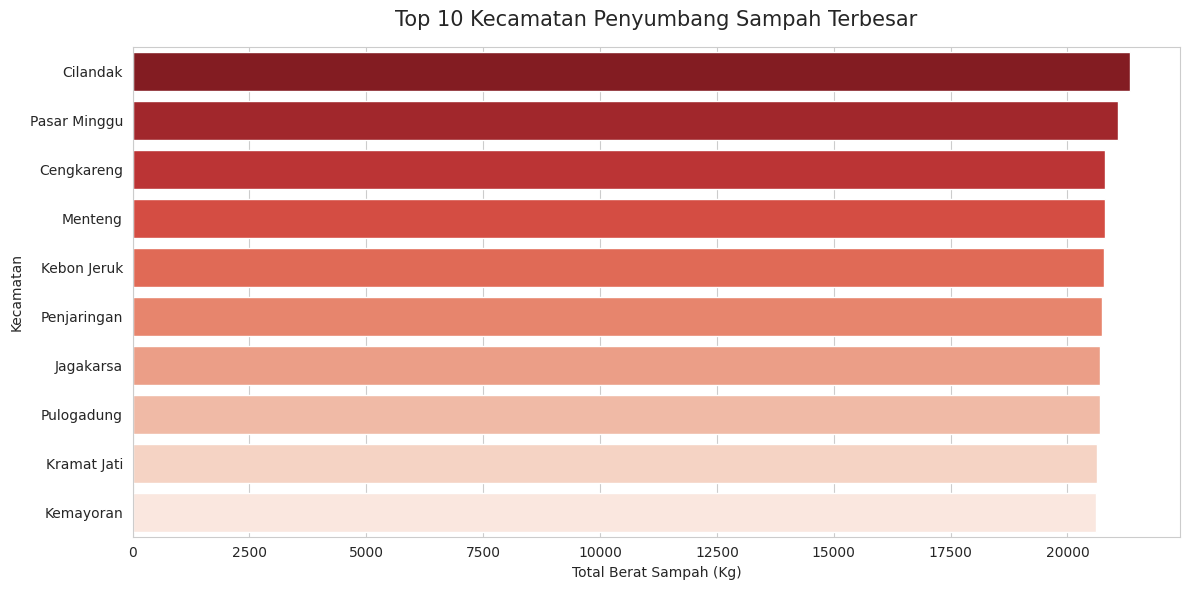

In [ ]:
plt.figure(figsize=(12, 6))
# Mengambil 10 kecamatan teratas
sns.barplot(
    x='berat_kg',
    y='kecamatan',
    data=sampah_per_kecamatan.head(10),
    palette='Reds_r'
)
plt.title('Top 10 Kecamatan Penyumbang Sampah Terbesar', fontsize=15, pad=15)
plt.xlabel('Total Berat Sampah (Kg)')
plt.ylabel('Kecamatan')
plt.tight_layout()
plt.show()

### Insight:
Dari analisis pertanyaan pertama, `Kecamatan mana yang menghasilkan sampah paling banyak?`, terlihat bahwa **Cilandak** adalah kecamatan yang menghasilkan total berat sampah tertinggi, diikuti oleh Pasar Minggu dan Cengkareng. Ini mengindikasikan bahwa upaya pengelolaan sampah mungkin perlu lebih difokuskan di area-area ini.

### Pertanyaan 2 : Jenis sampah apa yang paling sering muncul dan bagaimana metode pengelolaan terbaiknya?

/tmp/ipykernel_3375/1706530743.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3375/1706530743.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


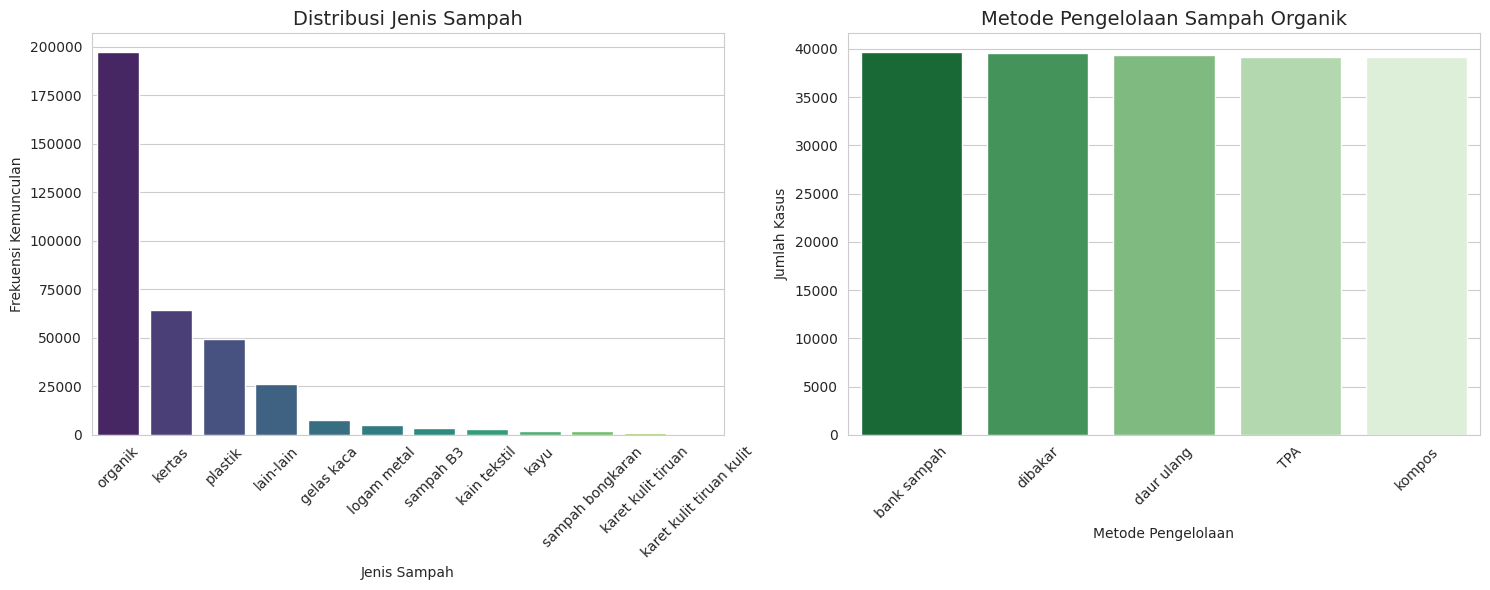

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Grafik 1: Proporsi Jenis Sampah
sns.barplot(
    x='jenis_sampah',
    y='jumlah_kemunculan',
    data=jenis_sampah_freq,
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title('Distribusi Jenis Sampah', fontsize=14)
axes[0].set_xlabel('Jenis Sampah')
axes[0].set_ylabel('Frekuensi Kemunculan')
axes[0].tick_params(axis='x', rotation=45)

# Grafik 2: Metode Pengelolaan khusus Organik
sns.barplot(
    x='metode_pengelolaan',
    y='count',
    data=pengelolaan_organik,
    palette='Greens_r',
    ax=axes[1]
)
axes[1].set_title('Metode Pengelolaan Sampah Organik', fontsize=14)
axes[1].set_xlabel('Metode Pengelolaan')
axes[1].set_ylabel('Jumlah Kasus')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Insight:
Untuk pertanyaan kedua, `Jenis sampah apa yang paling sering muncul dan bagaimana metode pengelolaan terbaiknya?`, grafik menunjukkan bahwa `organik` adalah jenis sampah yang paling dominan dengan jumlah jauh di atas jenis sampah lainnya. Metode pengelolaan yang paling sering tercatat untuk sampah organik adalah `bank sampah`, `dibakar`, dan `daur ulang`, dengan `kompos` juga memiliki proporsi yang signifikan. Ini menunjukkan bahwa fokus pengelolaan sampah organik saat ini mencakup berbagai pendekatan. Jenis sampah lain seperti `kertas` dan `plastik` juga signifikan, menunjukkan pentingnya program daur ulang dan pemilahan sampah yang efektif.

### Pertanyaan 3 : Apakah cuaca mempengaruhi jumlah berat sampah yang dihasilkan?

/tmp/ipykernel_3375/3750168586.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


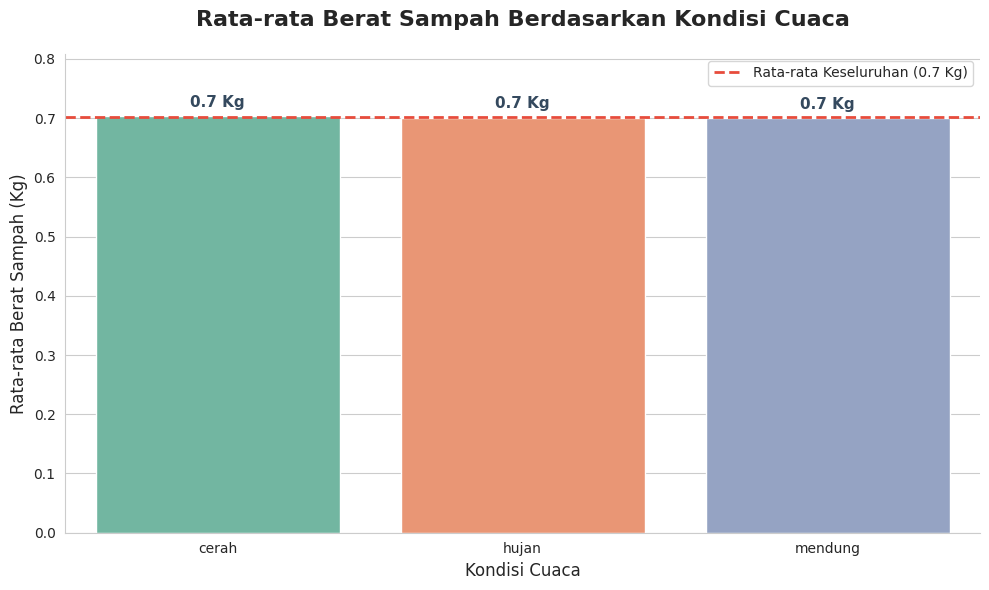

In [ ]:
berat_per_cuaca = df.groupby('cuaca')['berat_kg'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='cuaca',
    y='berat_kg',
    data=berat_per_cuaca,
    palette='Set2'
)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f} Kg",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=11, fontweight='bold', color='#34495e')

mean_berat = df['berat_kg'].mean()
plt.axhline(mean_berat, color='#e74c3c', linestyle='--', linewidth=2, label=f'Rata-rata Keseluruhan ({mean_berat:.1f} Kg)')

plt.title('Rata-rata Berat Sampah Berdasarkan Kondisi Cuaca', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Kondisi Cuaca', fontsize=12)
plt.ylabel('Rata-rata Berat Sampah (Kg)', fontsize=12)
plt.ylim(0, berat_per_cuaca['berat_kg'].max() * 1.15)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Insight:
Analisis untuk pertanyaan ketiga, `Apakah cuaca mempengaruhi jumlah berat sampah yang dihasilkan?`, menunjukkan bahwa meskipun ada sedikit perbedaan rata-rata berat sampah antara kondisi cuaca `cerah`, `hujan`, dan `mendung`, perbedaannya tidak terlalu signifikan. Bar plot juga menunjukkan distribusi rata-rata berat sampah yang serupa di ketiga kategori cuaca. Ini menyiratkan bahwa cuaca mungkin bukan faktor utama yang mempengaruhi *jumlah* berat sampah secara drastis, meskipun mungkin ada pengaruh pada *jenis* sampah atau pola pengumpulan.

### Kesimpulan:
Berdasarkan analisis data sampah yang telah dilakukan, ada beberapa kesimpulan:

1.  **Kecamatan Penyumbang Sampah Terbesar:** Kecamatan **Cilandak** teridentifikasi sebagai penyumbang berat sampah tertinggi, diikuti oleh Pasar Minggu dan Cengkareng. Hal ini menunjukkan perlunya fokus dan strategi pengelolaan sampah yang lebih intensif di wilayah-wilayah tersebut.

2.  **Jenis Sampah Dominan dan Pengelolaan:** Sampah **organik** adalah jenis sampah yang paling dominan dalam dataset. Metode pengelolaan yang paling sering tercatat untuk sampah organik adalah `bank sampah`, `dibakar`, dan `daur ulang`, dengan `kompos` juga memiliki proporsi yang signifikan. Untuk mengelola sampah organik secara lebih efektif dan berkelanjutan, metode seperti pengomposan atau produksi biogas dapat menjadi prioritas. Selain itu, proporsi sampah anorganik seperti kertas dan plastik yang signifikan menekankan pentingnya program daur ulang yang terstruktur dan edukasi masyarakat mengenai pemilahan sampah di sumbernya.

3.  **Pengaruh Cuaca:** Analisis menunjukkan bahwa kondisi cuaca (cerah, hujan, mendung) memiliki **pengaruh yang tidak signifikan** terhadap jumlah berat sampah yang dihasilkan. Fluktuasi berat sampah cenderung stabil terlepas dari kondisi cuaca, menunjukkan bahwa faktor lain mungkin lebih berpengaruh terhadap volume sampah harian.

Secara keseluruhan, temuan ini memberikan dasar bagi pemerintah daerah dan pemangku kepentingan lainnya untuk merancang kebijakan dan program pengelolaan sampah yang lebih tepat sasaran, dengan memprioritaskan area dan jenis sampah tertentu, serta mengoptimalkan strategi berdasarkan karakteristik data yang ada.